In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

df = pd.read_csv(r'C:\Users\sahil\fraud_project\creditcard.csv')

df = df.rename(columns={
    'Time'  : 'time_seconds',
    'Class' : 'is_fraud'
})

print(df.shape)
print("Data loaded successfully")

(284807, 31)
Data loaded successfully


In [3]:
# create hour column from time_seconds
df['hour'] = (df['time_seconds'] / 3600).astype(int) % 24

# drop time_seconds - not needed for model
df = df.drop('time_seconds', axis=1)

# normalize Amount column
df['Amount'] = (df['Amount'] - df['Amount'].mean()) / df['Amount'].std()

print("Hour column added")
print("Amount normalized")
print(df.shape)
print(df['Amount'].describe())

Hour column added
Amount normalized
(284807, 31)
count    2.848070e+05
mean     2.235360e-17
std      1.000000e+00
min     -3.532288e-01
25%     -3.308395e-01
50%     -2.652710e-01
75%     -4.471699e-02
max      1.023621e+02
Name: Amount, dtype: float64


In [5]:
# separate features and target
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

# split data 80% train 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training size:   {X_train.shape}")
print(f"Testing size:    {X_test.shape}")
print(f"Train fraud count: {y_train.sum()}")
print(f"Test fraud count:  {y_test.sum()}")

Training size:   (227845, 30)
Testing size:    (56962, 30)
Train fraud count: 394
Test fraud count:  98


In [7]:
print(f"Before SMOTE - Fraud count: {y_train.sum()}")
print(f"Before SMOTE - Legit count: {(y_train==0).sum()}")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE - Fraud count: {y_train_sm.sum()}")
print(f"After SMOTE - Legit count: {(y_train_sm==0).sum()}")
print(f"Total training samples: {len(X_train_sm)}")

Before SMOTE - Fraud count: 394
Before SMOTE - Legit count: 227451

After SMOTE - Fraud count: 227451
After SMOTE - Legit count: 227451
Total training samples: 454902


## SMOTE Explanation

Before SMOTE the training data had only 394 fraud samples vs 227,451 legit samples.
This extreme imbalance would cause the model to predict legit every time and ignore fraud completely.

SMOTE creates synthetic fraud samples by interpolating between existing fraud samples.
After SMOTE both classes have 227,451 samples each — perfectly balanced.

Important: SMOTE applied ONLY on training data — never on test data.
Applying on test data would give fake evaluation
 results.

In [11]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train_sm, y_train_sm)

print("Model training complete")

Model training complete


In [13]:
y_pred      = rf.predict(X_test)
y_pred_prob = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Legit','Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob):.4f}")

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.66      0.86      0.74        98

    accuracy                           1.00     56962
   macro avg       0.83      0.93      0.87     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9811


In [15]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(f"True Negatives  (legit correctly passed):  {cm[0,0]:,}")
print(f"False Positives (legit flagged as fraud):  {cm[0,1]:,}")
print(f"False Negatives (fraud missed):            {cm[1,0]:,}")
print(f"True Positives  (fraud correctly caught):  {cm[1,1]:,}")

Confusion Matrix:
True Negatives  (legit correctly passed):  56,820
False Positives (legit flagged as fraud):  44
False Negatives (fraud missed):            14
True Positives  (fraud correctly caught):  84


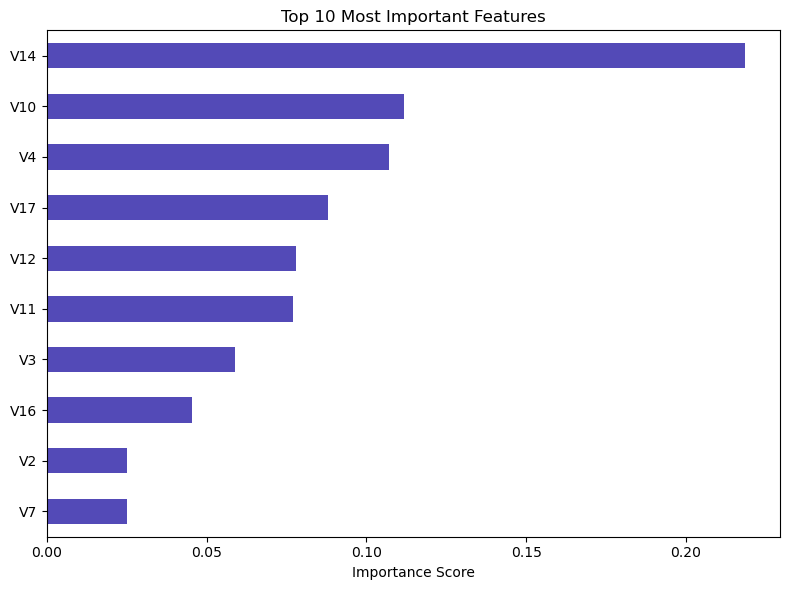

Top 3 features: ['V14', 'V10', 'V4']


In [17]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)

fig, ax = plt.subplots(figsize=(8,6))
feat_imp.nlargest(10).sort_values().plot(kind='barh', ax=ax, color='#534AB7')

ax.set_title('Top 10 Most Important Features')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig(r'C:\Users\sahil\fraud_project\screenshots\09_feature_importance.png')
plt.show()

print(f"Top 3 features: {feat_imp.nlargest(3).index.tolist()}")

In [19]:
import pickle

with open(r'C:\Users\sahil\fraud_project\fraud_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

print("Model saved successfully")

Model saved successfully


In [21]:
y_pred      = rf.predict(X_test)
y_pred_prob = rf.predict_proba(X_test)[:, 1]

test_results = X_test.copy()
test_results['actual_fraud']    = y_test.values
test_results['predicted_fraud'] = y_pred
test_results['fraud_probability'] = y_pred_prob

test_results['risk_band'] = pd.cut(
    test_results['fraud_probability'],
    bins  = [0, 0.3, 0.6, 0.85, 1.0],
    labels= ['Low', 'Medium', 'High', 'Critical']
)

print(test_results['risk_band'].value_counts())
print(f"\nTotal rows: {len(test_results)}")

risk_band
Low         56463
Medium        111
Critical       83
High           26
Name: count, dtype: int64

Total rows: 56962


In [23]:
from sqlalchemy import create_engine

server = r'LAPTOP-RNCU5CQF\SQLEXPRESS'  

engine = create_engine(
    f'mssql+pyodbc://{server}/FraudDetectionDB'
    '?driver=ODBC+Driver+17+for+SQL+Server'
    '&trusted_connection=yes'
)

test_results['risk_band'] = test_results['risk_band'].astype(str)

test_results.to_sql(
    name      = 'fraud_predictions',
    con       = engine,
    if_exists = 'replace',
    index     = False
)

print(f"Done. {len(test_results)} rows pushed to SQL Server.")

Done. 56962 rows pushed to SQL Server.


In [25]:
# fill nan risk_band with 'Low'
test_results['risk_band'] = test_results['risk_band'].astype(str)
test_results['risk_band'] = test_results['risk_band'].replace('nan', 'Low')

# push again replacing old table
test_results.to_sql(
    name      = 'fraud_predictions',
    con       = engine,
    if_exists = 'replace',
    index     = False
)

print(f"Done. {len(test_results)} rows pushed to SQL Server.")

Done. 56962 rows pushed to SQL Server.
